# **Pinecone implementation of ImageNet and CNN**

- https://www.pinecone.io/learn/series/image-search/imagenet/

In [ ]:
from datasets import load_dataset

In [6]:
imagenet = load_dataset(
    'Maysee/tiny-imagenet',
    split='valid'
)
imagenet

Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})

In [7]:
imagenet[0]  # single record

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64>,
 'label': 0}

In [8]:
# check image type
type(imagenet[0]['image'])

PIL.JpegImagePlugin.JpegImageFile

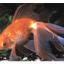

In [9]:
# view PIL images like so (in notebooks):
imagenet[0]['image']

In [10]:
# check for RGB, this image is okay
imagenet[0]['image'].mode

'RGB'

In [11]:
# 'L' is grayscale, and must be converted to RGB
imagenet[201]['image'].mode

'L'

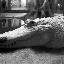

In [12]:
imagenet[201]['image']  # we can see it is grayscale

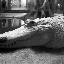

In [13]:
img = imagenet[201]['image'].convert('RGB')
img  # it will still be shown as grayscale

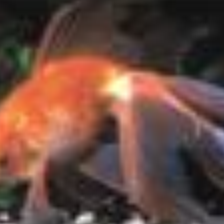

In [14]:
from torchvision import transforms

# resize and crop to 224x224
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224)
])

new_img = preprocess(imagenet[0]['image'])
new_img

In [15]:
# resize and crop to 224x224
preprocess = transforms.Compose([
    transforms.ToTensor(),  # convert from PIL image to tensor before norm to avoid error
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# final result is normalized tensor of shape (3, 224, 224)
new_img = preprocess(new_img)

In [16]:
from tqdm.auto import tqdm
import torch

# define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

inputs = []

for image in tqdm(imagenet[:50]['image']):
    # convert from grayscale to RBG
    if image.mode != 'RGB':
        image = image.convert("RGB")
    # prepocessing
    input_tensor = preprocess(image)
    inputs.append(input_tensor)

# convert batch list to tensor (as expected by the model)
inputs = torch.stack(inputs)
inputs.size()

  0%|          | 0/50 [00:00<?, ?it/s]

torch.Size([50, 3, 224, 224])

In [17]:
import torch

# load pretrained alexnet from pytorch hub
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)
model.eval()  # set model to evaluation mode (for inference)

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to C:\Users\joeln/.cache\torch\hub\v0.10.0.zip
c:\Users\joeln\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\joeln\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\joeln/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:04<00:00, 51.2MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [18]:
# move to device if available
device = torch.device(
    'cuda' if torch.cuda.is_available() else (
        'mps' if torch.backends.mps.is_available() else 'cpu'
    )
)

In [19]:
# move inputs and model to device
inputs = inputs.to(device)
model.to(device)

# run the model
with torch.no_grad():
    output = model(inputs).detach()
print(output.shape)
output

torch.Size([50, 1000])


tensor([[ 8.1108, 14.6574, -0.1506,  ...,  5.8944,  1.3372, -5.4662],
        [ 2.7997,  9.3263,  2.4853,  ..., -1.7907, -0.1574, -1.7162],
        [ 7.3128, 16.8722,  1.3526,  ...,  3.2606,  0.8557, -3.7938],
        ...,
        [ 3.5170, 10.5402, -3.2779,  ...,  1.9780,  0.7336, -1.1573],
        [ 4.2826, 13.0668,  1.2182,  ..., -1.0022,  2.9048, -5.2177],
        [ 4.0053,  8.5589, -2.4859,  ...,  2.4926,  2.2112, -2.7797]])

In [20]:
# prediction
preds = torch.argmax(output, dim=1).cpu().numpy()
print(preds.shape)
preds

(50,)


array([  1,   1,   1,   1, 392,   1, 149,   1, 392,   1,   1,   1, 782,
         1, 392,  73, 392,   1,  29, 973, 392,  73, 995,   1,   1,   1,
         1, 206,   1,   1,   1,   1,   1,   1,   1,   1, 335,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1])

In [21]:
import requests

res = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")

In [22]:
pred_labels = res.text.split('\n')
print(f"{len(pred_labels)}\n{pred_labels[1]}")

1000
goldfish


In [23]:
sum(preds == 1) / len(preds)

np.float64(0.72)